# SynthACticBench O1: fixed versus staged leaf-size policies

This notebook loads the trajectories created by `submit_fixed_policies.py` and `submit_adaptive_policy.py`. It verifies that all comparison settings match and that the staged run shares its first 150 evaluations with fixed leaf size 3.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

HERE = Path("/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o1_deterministic/leaf_policies/01_initial")
OUTPUT_DIRECTORY = HERE / "smac_output"
POLICIES = ("fixed_leaf_1", "fixed_leaf_2", "fixed_leaf_3", "staged_leaf_3_2_1")

In [2]:
def load_trajectory(policy):
    candidates = list((OUTPUT_DIRECTORY / policy).rglob("trajectory.json"))
    if not candidates:
        raise FileNotFoundError(f"No trajectory found for {policy}")
    path = max(candidates, key=lambda candidate: candidate.stat().st_mtime)
    result = json.loads(path.read_text())
    if result["n_trials"] != 500:
        raise ValueError(f"{path} contains {result['n_trials']} rather than 500 trials")
    return result


results = {policy: load_trajectory(policy) for policy in POLICIES}

comparison_fields = (
    "problem",
    "smac_seed",
    "problem_seed",
    "instance_seed",
    "pythonhashseed",
    "n_instances",
    "instance_map",
    "n_trials",
)
reference = results["fixed_leaf_3"]
for policy, result in results.items():
    for field in comparison_fields:
        assert result[field] == reference[field], (policy, field)

assert results["staged_leaf_3_2_1"]["objective_value"][:150] == results["fixed_leaf_3"]["objective_value"][:150]
print("All settings match and the first 150 staged evaluations equal fixed leaf 3.")
print("Observed staged transitions:", results["staged_leaf_3_2_1"]["transitions"])

All settings match and the first 150 staged evaluations equal fixed leaf 3.
Observed staged transitions: [[0, 3], [150, 2], [302, 1]]


In [3]:
summary = pd.DataFrame(
    [
        {
            "policy": policy,
            "incumbent_cost": result["incumbent_cost"],
            "unique_configurations": len(result["trials_per_config"]),
            "surrogate_fits_estimate": 1 + (len(result["trials_per_config"]) - 1) // 8,
        }
        for policy, result in results.items()
    ]
)
summary

,policy,incumbent_cost,unique_configurations,surrogate_fits_estimate
0,fixed_leaf_1,-289163.164321,355,45
1,fixed_leaf_2,-279996.772183,337,43
2,fixed_leaf_3,-311023.863034,337,43
3,staged_leaf_3_2_1,-288074.839334,373,47


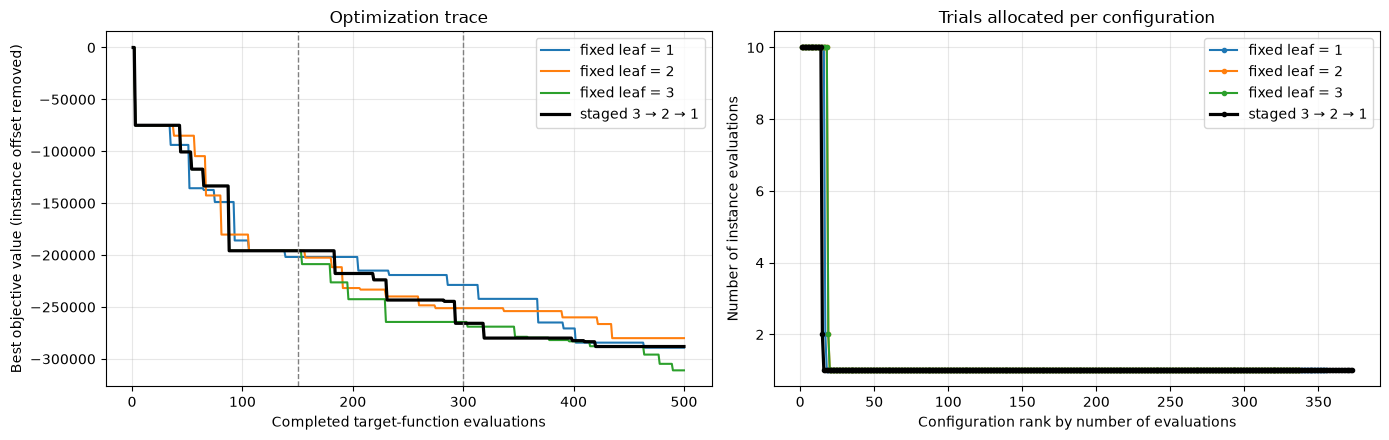

In [4]:
labels = {
    "fixed_leaf_1": "fixed leaf = 1",
    "fixed_leaf_2": "fixed leaf = 2",
    "fixed_leaf_3": "fixed leaf = 3",
    "staged_leaf_3_2_1": "staged 3 → 2 → 1",
}
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for policy, result in results.items():
    style = {"color": "black", "linewidth": 2.3} if policy == "staged_leaf_3_2_1" else {}
    axes[0].plot(result["iteration"], result["best_so_far"], label=labels[policy], **style)
    counts = sorted(result["trials_per_config"].values(), reverse=True)
    axes[1].plot(range(1, len(counts) + 1), counts, marker=".", label=labels[policy], **style)

axes[0].axvline(150, color="grey", linestyle="--", linewidth=1)
axes[0].axvline(300, color="grey", linestyle="--", linewidth=1)
axes[0].set(
    xlabel="Completed target-function evaluations",
    ylabel="Best objective value (instance offset removed)",
    title="Optimization trace",
)
axes[1].set(
    xlabel="Configuration rank by number of evaluations",
    ylabel="Number of instance evaluations",
    title="Trials allocated per configuration",
)
for axis in axes:
    axis.grid(alpha=0.3)
    axis.legend()
plt.tight_layout()
plt.show()